# Predicting NYC Housing Prices [Work in Progress]

**Current Status**: Actively optimizing spatial models and expanding feature engineering.  
**Latest Milestone**: Implemented Moran's I. 

## Goal of the Project
The goal of this project is to **predict housing prices in New York City** using a dataset that includes features such as property type, neighborhood, number of bedrooms, number of bathrooms, and area. By building a robust regression model, we aim to:

1. **Understand the key factors** that influence housing prices in NYC.
2. **Provide accurate price predictions** that can assist buyers, sellers, and real estate professionals in making informed decisions.
3. **Explore and visualize trends** in the housing market, such as the impact of location, property size, and type on pricing.

This project will involve:
- **Exploratory Data Analysis (EDA)** to uncover patterns and relationships in the data.
- **Feature Engineering** to create meaningful predictors from the raw data.
- **Model Development** using machine learning algorithms to predict housing prices.
- **Evaluation** of model performance using metrics like RMSE and R².

**Project Status**:
- ✅ Exploratory Data Analysis (Completed)  
- ✅ Baseline Model Development (Completed)  
- [ ] Spatial Feature Optimization (In Progress)
- [ ] K-fold Target Encoding (Planned)
- [ ] Model Selection and Optimization (Planned)

SECTION 1

# Load, clean and first look the data

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import probplot

In [3]:
import geopandas as gpd

In [4]:
from sklearn.utils.parallel import Parallel, delayed

In [5]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.parallel")

In [6]:
# Import dataset
file = '../data/processed/housing_with_features.csv'

In [7]:
# load the data
df = pd.read_csv(file)

SECTION 3

## Modelling

## Building basiline regression on original dataset

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

In [9]:
parameter_columns = ['beds', 'bath', 'propertysqft']
target_column = ['price']

In [10]:
def run_regression(df, feature_columns, target_column='price', cv_folds=5):
    X = df[feature_columns]
    y = df[target_column]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print('MAE: ', mae)
    print('R2: ', r2)
    scores = cross_val_score(model, X, y, cv=cv_folds, scoring='r2')
    print(f"Cross-validated R2: {scores.mean():.3f}")
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
    plt.xlabel('Actual price')
    plt.ylabel('Predicted price')
    plt.title('Actual vs Predicted')
    plt.show()
    print(model.coef_)

MAE:  1446041.864565475
R2:  0.11111155927349747
Cross-validated R2: 0.216


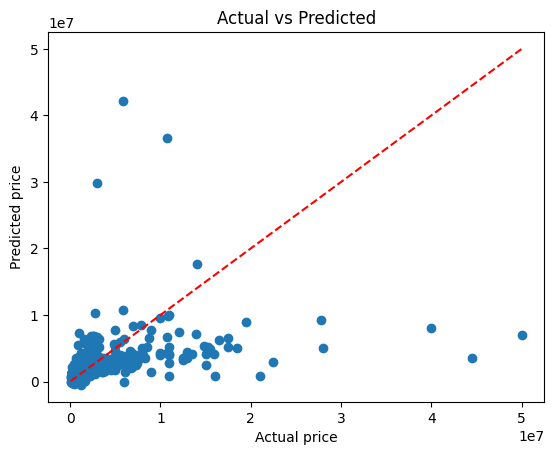

[-318153.01456693  687879.93497455     756.69855659]


In [11]:
# ID: 1
run_regression(df, parameter_columns)

In [12]:
experiment_log = pd.DataFrame(columns=[
    'ID', 'Model', 'Features', 'Params', 'MAE', 'R2', 'Cross_val_R2', 'Comment'
])

In [13]:
new_entry = {
    'ID': 1,
    'Model': 'LinearRegression',
    'Features': parameter_columns,
    'Params': None,
    'MAE': 1446041.86,
    'R2': 0.111,
    'Cross_val_R2': 0.216,
    'Comment': 'Baseline linear regression'
}
experiment_log.loc[len(experiment_log)] = new_entry

In [14]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.86,0.111,0.216,Baseline linear regression


## Building baseline regression on log dataset

In [15]:
parameter_columns_log = ['log_beds', 'log_bath', 'log_area']
target_column = ['price']

MAE:  1669929.608719539
R2:  0.24881386352705348
Cross-validated R2: 0.223


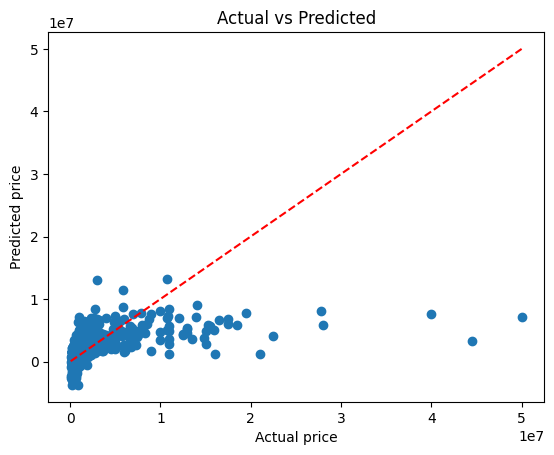

[-1167950.71397377  2411755.68244424  2716887.08000101]


In [16]:
# ID:b 2
run_regression(df, parameter_columns_log)

In [17]:
new_entry = {
    'ID': 2,
    'Model': 'LinearRegression',
    'Features': parameter_columns_log,
    'Params': None,
    'MAE': 1669929.60,
    'R2': 0.248,
    'Cross_val_R2': 0.223,
    'Comment': ''
}
experiment_log.loc[len(experiment_log)] = new_entry

In [18]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.86,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.60,0.248,0.223,


## Regression on all non spatial data

In [19]:
all_non_spatial_features = [ 
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area']

MAE:  1590792.6571588595
R2:  0.35156558563553075
Cross-validated R2: 0.304


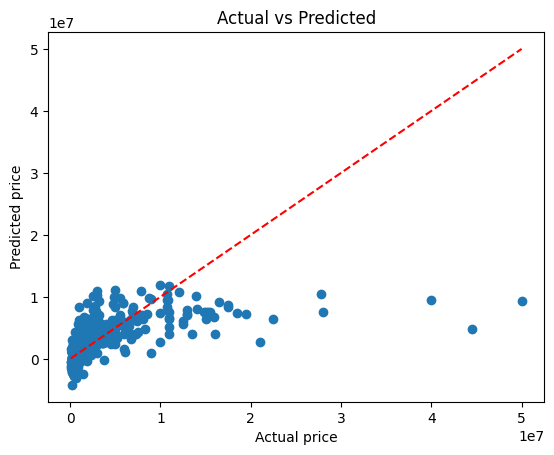

[  555646.29543109 -1597179.87464376 -2909013.68318822 -1409485.91392529
 -1171801.44891972  1266946.1906757  -4562212.45282225   547410.78405773
  2480724.2174317    128062.22187921  2629210.54259997]


In [20]:
# ID: 3
run_regression(df, all_non_spatial_features)

In [21]:
new_entry = {
    'ID': 3,
    'Model': 'LinearRegression',
    'Features': all_non_spatial_features,
    'Params': None,
    'MAE': 1590792.65,
    'R2': 0.351,
    'Cross_val_R2': 0.304,
    'Comment': ''
}
experiment_log.loc[len(experiment_log)] = new_entry

In [22]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.86,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.60,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.65,0.351,0.304,


In [23]:
all_features = [
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area', 'borough_Manhattan',
       'borough_Brooklyn', 'borough_Queens']

MAE:  1560379.0433904114
R2:  0.3827027392621428
Cross-validated R2: 0.349


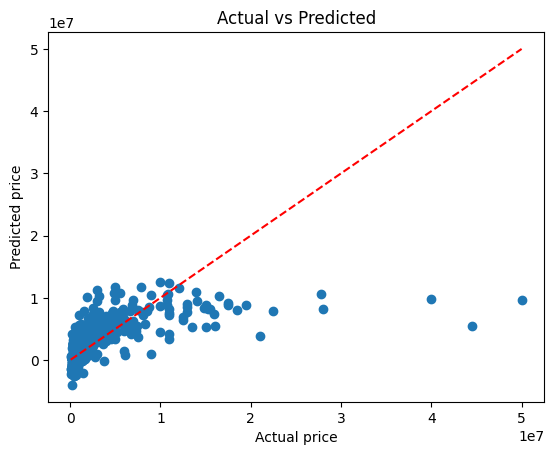

[  474680.65455211  -478303.7244891  -1582451.60172841  -550876.4349389
  -524986.97188908  1745970.99032531 -3940875.08853345   541844.23062895
  2009734.72338624  -152619.33881072  2297018.8524683   2692770.66048107
   530010.35736119   466159.3157771 ]


In [24]:
# ID: 4
run_regression(df, all_features)

In [25]:
new_entry = {
    'ID': 4,
    'Model': 'LinearRegression',
    'Features': all_features,
    'Params': None,
    'MAE': 1560379.043,
    'R2': 0.382,
    'Cross_val_R2': 0.349,
    'Comment': 'Only lat long missing'
}
experiment_log.loc[len(experiment_log)] = new_entry

In [26]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing


In [27]:
all_non_log_features = ['beds', 'bath', 'propertysqft',  
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 
       'area_missing', 'borough_Manhattan',
       'borough_Brooklyn', 'borough_Queens']

MAE:  1471016.517942964
R2:  0.2753667787708399
Cross-validated R2: 0.349


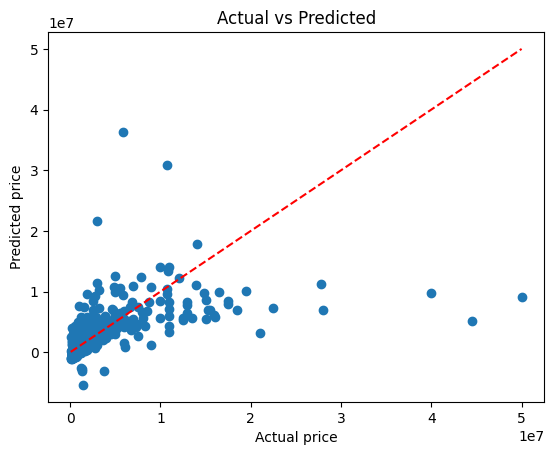

[ 2.97638620e+04  4.90771184e+05  6.75123780e+02  7.26628493e+05
  4.42058543e+05 -5.19551662e+05  1.08773988e+05  5.20260379e+04
  2.60199683e+06 -7.38073574e+06  1.84832767e+05  2.84576083e+06
  4.75287822e+05  4.18312846e+05]


In [28]:
# ID: 5
run_regression(df, all_non_log_features)

In [29]:
new_entry = {
    'ID': 5,
    'Model': 'LinearRegression',
    'Features': all_non_log_features,
    'Params': None,
    'MAE': 1471016.51,
    'R2': 0.275,
    'Cross_val_R2': 0.349,
    'Comment': ''
}
experiment_log.loc[len(experiment_log)] = new_entry

In [30]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing
4,5,LinearRegression,"[beds, bath, propertysqft, type_Condo for sale...",None,1471016.510,0.275,0.349,


In [31]:
df.columns

Index(['Unnamed: 0', 'brokertitle', 'type', 'price', 'beds', 'bath',
       'propertysqft', 'formatted_address', 'latitude', 'longitude',
       'log_price', 'price_segment', 'eda_type_clean', 'log_beds', 'beds_sqrt',
       'beds_asinh', 'beds_binned', 'log_bath', 'bath_binned', 'area_missing',
       'log_area', 'zip', 'borough', 'borough_Manhattan', 'borough_Brooklyn',
       'borough_Queens', 'price_per_sqft', 'log_pps', 'broker_count',
       'luxury_score', 'is_top_luxury_broker', 'type_Condo for sale',
       'type_House for sale', 'type_Multi-family home for sale', 'type_Other',
       'type_Pending', 'type_Townhouse for sale', 'is_upper', 'is_mid',
       'is_luxury', 'is_high_beds'],
      dtype='object')

In [32]:
all_features_with_lat_long = ['latitude',
       'longitude',
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds',
       'log_bath', 'area_missing', 'log_area',
       'borough_Manhattan', 'borough_Brooklyn', 'borough_Queens']

MAE:  1553327.3754859788
R2:  0.38213784271300466
Cross-validated R2: 0.350


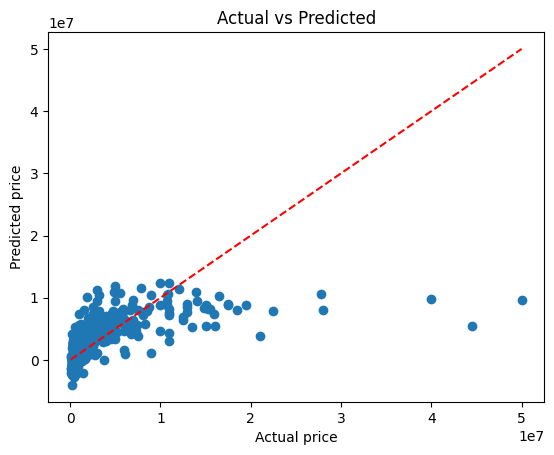

[ 2189473.3701768  -1639811.12963059   477682.35134632  -389512.51699997
 -1527673.38597787  -468057.31450404  -485339.69400879  1757206.04392228
 -3960136.69179932   536539.01811548  2005066.41864546  -164798.9506755
  2288696.39534765  2690435.53059101   794061.52560855   759287.78430662]


In [33]:
# ID: 6
run_regression(df, all_features_with_lat_long)

In [34]:
new_entry = {
    'ID': 6,
    'Model': 'LinearRegression',
    'Features': all_features_with_lat_long,
    'Params': None,
    'MAE': 1553327.37,
    'R2': 0.382,
    'Cross_val_R2': 0.350,
    'Comment': 'On adding lat long changes insignificant'
}
experiment_log.loc[len(experiment_log)] = new_entry

In [35]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing
4,5,LinearRegression,"[beds, bath, propertysqft, type_Condo for sale...",None,1471016.510,0.275,0.349,
5,6,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",None,1553327.370,0.382,0.350,On adding lat long changes insignificant


## Gradient Boosting Regressor

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

In [37]:
def run_gb_regressor(df, feature_columns, target_column='price', cv_folds=5):
    X = df[feature_columns]
    y = df[target_column]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
    )

    # Train and predict
    gbr.fit(X_train, y_train)
    y_pred = gbr.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print('MAE: ', mae)
    print('R2: ', r2)
    scores = cross_val_score(gbr, X, y, cv=cv_folds, scoring='r2')
    print(f"Cross-validated R²: {scores.mean():.3f}")
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
    plt.xlabel('Actual price')
    plt.ylabel('Predicted price')
    plt.title('Actual vs Predicted')
    plt.show()

    residuals = y_test - y_pred
    results_df = X_test.copy()
    results_df['actual_price'] = y_test
    results_df['predicted_price'] = y_pred
    results_df['residual'] = residuals
    results_df['pct_error'] = (residuals / y_test) * 100
    #return results_df

In [38]:
all_features_with_lat_long

['latitude',
 'longitude',
 'type_Condo for sale',
 'type_House for sale',
 'type_Multi-family home for sale',
 'type_Other',
 'type_Pending',
 'type_Townhouse for sale',
 'is_high_beds',
 'log_beds',
 'log_bath',
 'area_missing',
 'log_area',
 'borough_Manhattan',
 'borough_Brooklyn',
 'borough_Queens']

MAE:  873832.2399976306
R2:  0.468020605598079
Cross-validated R²: 0.580


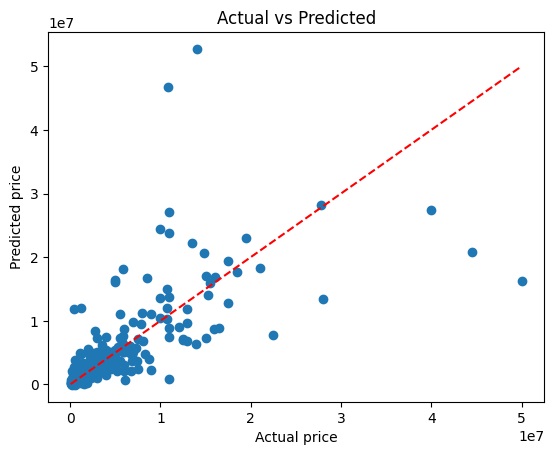

In [39]:
# ID: 7
run_gb_regressor(df, all_features_with_lat_long)

In [40]:
# This chart looks better then linear regression chart

In [41]:
new_entry = {
    'ID': 7,
    'Model': 'GradientBoostingRegressor',
    'Features': all_features_with_lat_long,
    'Params': {'n_estimators':500,
               'learning_rate':0.05,
               'max_depth':4,
               'subsample':0.8,
               'min_samples_leaf':5},
    'MAE': 873832.23,
    'R2': 0.468,
    'Cross_val_R2': 0.580,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [42]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing
4,5,LinearRegression,"[beds, bath, propertysqft, type_Condo for sale...",None,1471016.510,0.275,0.349,
5,6,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",None,1553327.370,0.382,0.350,On adding lat long changes insignificant
6,7,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",873832.230,0.468,0.580,


In [43]:
# I will try to add spatial features and see what will happend

In [44]:
# Central Park South (5th Ave edge - most prestigious side)
park_coords = (40.7666, -73.9712)

# Manhattan distance
df['central_part_dist'] = (
    abs(df['latitude'] - park_coords[0]) + 
    abs(df['longitude'] - park_coords[1])
)

In [45]:
# Times Square coordinates
tsq_coords = (40.7580, -73.9855)

# Manhattan distance
df['tsq_dist'] = (
    abs(df['latitude'] - tsq_coords[0]) + 
    abs(df['longitude'] - tsq_coords[1])
)

In [46]:
new_entry = {
    'ID': None,
    'Model': 'Feature Engineering',
    'Features': ['central_part_dist','tsq_dist'],
    'Params': '',
    'MAE': np.nan,
    'R2': np.nan,
    'Cross_val_R2': np.nan,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [47]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing
4,5,LinearRegression,"[beds, bath, propertysqft, type_Condo for sale...",None,1471016.510,0.275,0.349,
5,6,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",None,1553327.370,0.382,0.350,On adding lat long changes insignificant
6,7,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",873832.230,0.468,0.580,
7,None,Feature Engineering,"[central_part_dist, tsq_dist]",,NaN,NaN,NaN,


In [48]:
df.columns

Index(['Unnamed: 0', 'brokertitle', 'type', 'price', 'beds', 'bath',
       'propertysqft', 'formatted_address', 'latitude', 'longitude',
       'log_price', 'price_segment', 'eda_type_clean', 'log_beds', 'beds_sqrt',
       'beds_asinh', 'beds_binned', 'log_bath', 'bath_binned', 'area_missing',
       'log_area', 'zip', 'borough', 'borough_Manhattan', 'borough_Brooklyn',
       'borough_Queens', 'price_per_sqft', 'log_pps', 'broker_count',
       'luxury_score', 'is_top_luxury_broker', 'type_Condo for sale',
       'type_House for sale', 'type_Multi-family home for sale', 'type_Other',
       'type_Pending', 'type_Townhouse for sale', 'is_upper', 'is_mid',
       'is_luxury', 'is_high_beds', 'central_part_dist', 'tsq_dist'],
      dtype='object')

In [49]:
all_features_expanded = ['latitude',
       'longitude', 
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds',
       'log_bath', 'area_missing', 'log_area',
       'borough_Manhattan', 'borough_Brooklyn', 'borough_Queens',
       'central_part_dist', 'tsq_dist']

MAE:  1549143.3654935362
R2:  0.38846865275035547
Cross-validated R2: 0.353


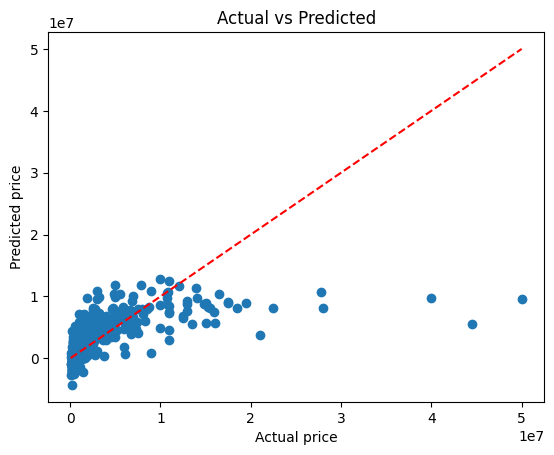

[-3488063.45607853  1985046.95177345   384618.9786169   -329895.34872157
 -1502153.09267745  -492790.07965018  -432912.08079513  1788509.56801503
 -4064345.31799839   534087.07706934  2039704.27678108  -207465.73710609
  2258285.00925276  1298842.14837206  -644368.72791541  -342946.78975136
  2662156.62937853 -9735588.49043202]


In [50]:
# ID: 8
run_regression(df, all_features_expanded)

In [51]:
# Nothing changed in linear regression

In [52]:
new_entry = {
    'ID': 8,
    'Model': 'LinearRegression',
    'Features': all_features_expanded,
    'Params': '',
    'MAE': 1549143.36,
    'R2': 0.388,
    'Cross_val_R2': 0.353,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

MAE:  843038.0630641275
R2:  0.5464847378893849
Cross-validated R²: 0.589


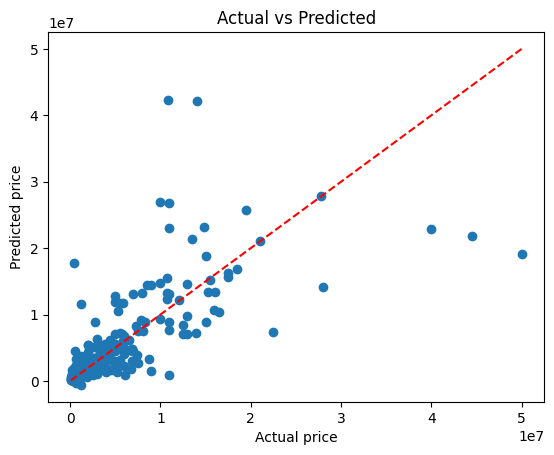

In [53]:
# ID: 9
run_gb_regressor(df, feature_columns=all_features_expanded)

In [54]:
# Gradient boosting regressor improved visually and by R2 score

In [55]:
new_entry = {
    'ID': 9,
    'Model': 'GradientBoostingRegressor',
    'Features': all_features_expanded,
    'Params': {'n_estimators':500,
               'learning_rate':0.05,
               'max_depth':4,
               'subsample':0.8,
               'min_samples_leaf':5},
    'MAE': 843038.06,
    'R2': 0.546,
    'Cross_val_R2': 0.589,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [56]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing
4,5,LinearRegression,"[beds, bath, propertysqft, type_Condo for sale...",None,1471016.510,0.275,0.349,
5,6,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",None,1553327.370,0.382,0.350,On adding lat long changes insignificant
6,7,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",873832.230,0.468,0.580,
7,None,Feature Engineering,"[central_part_dist, tsq_dist]",,NaN,NaN,NaN,
8,8,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",,1549143.360,0.388,0.353,
9,9,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",843038.060,0.546,0.589,


In [57]:
segment_features = [
    'beds', 'bath', 'propertysqft', 
    'borough_Manhattan',
    'type_Condo for sale', 'type_Townhouse for sale',
    'central_part_dist', 'tsq_dist'
]

<Axes: >

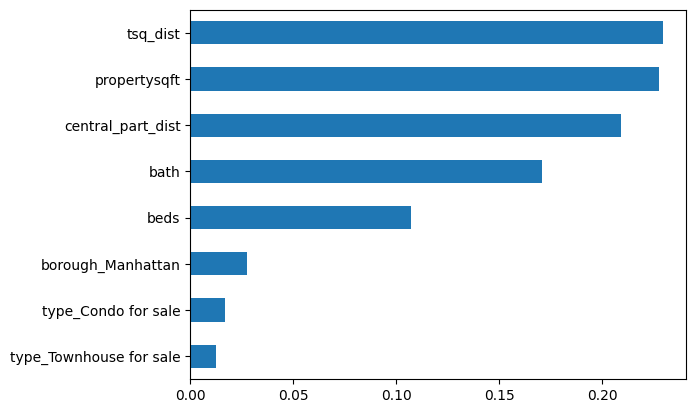

In [58]:
from sklearn.ensemble import RandomForestClassifier

# Train classifier to predict segment
segment_model = RandomForestClassifier().fit(
    df[segment_features],
    df['price_segment']
)

# Get feature importance
pd.Series(
    segment_model.feature_importances_,
    index=segment_features
).sort_values().plot(kind='barh')

<Axes: >

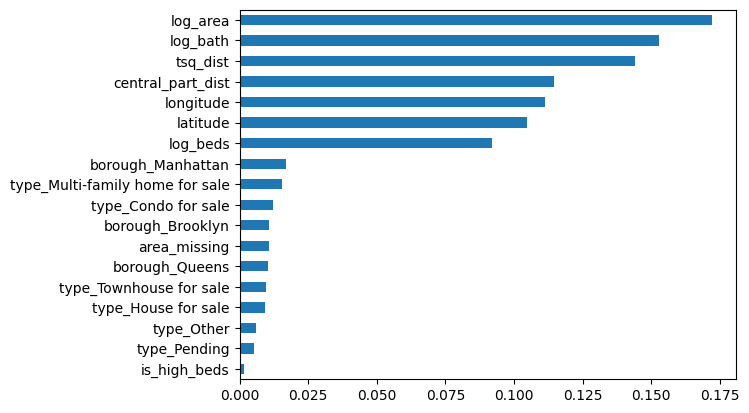

In [59]:
# Train classifier to predict segment
segment_model = RandomForestClassifier().fit(
    df[all_features_expanded],
    df['price_segment']
)

# Get feature importance
pd.Series(
    segment_model.feature_importances_,
    index=all_features_expanded
).sort_values().plot(kind='barh')

In [60]:
from sklearn.ensemble import RandomForestRegressor

<Axes: >

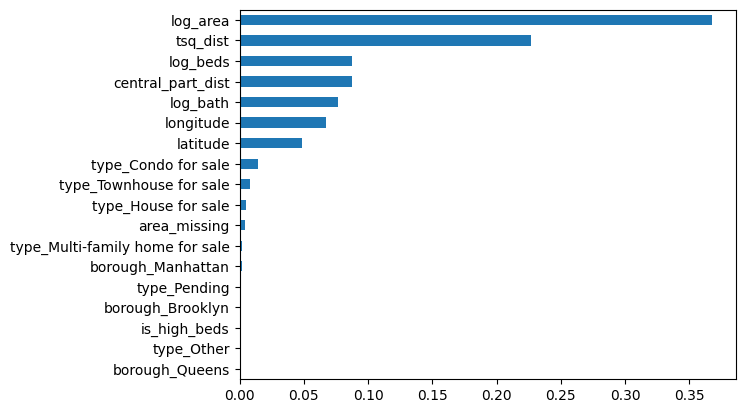

In [61]:
# RandomForestRegressor
segment_model = RandomForestRegressor().fit(
    df[all_features_expanded],
    df['price']
)

# Get feature importance
pd.Series(
    segment_model.feature_importances_,
    index=all_features_expanded
).sort_values().plot(kind='barh')

In [62]:
all_features_expanded

['latitude',
 'longitude',
 'type_Condo for sale',
 'type_House for sale',
 'type_Multi-family home for sale',
 'type_Other',
 'type_Pending',
 'type_Townhouse for sale',
 'is_high_beds',
 'log_beds',
 'log_bath',
 'area_missing',
 'log_area',
 'borough_Manhattan',
 'borough_Brooklyn',
 'borough_Queens',
 'central_part_dist',
 'tsq_dist']

MAE: и979,173
R2: 0.404
CV R2: 0.423 ± 0.032


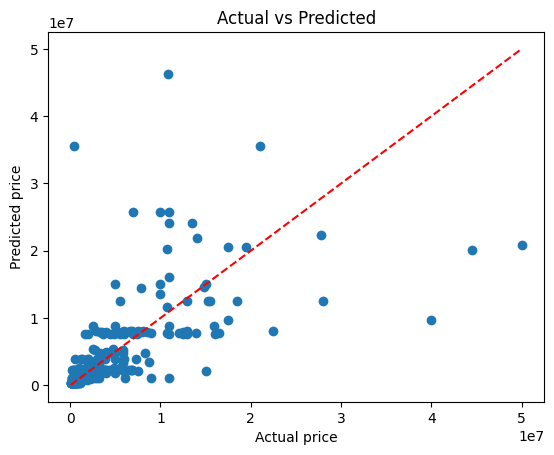

In [63]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

X = df[all_features_expanded]
y = df['price'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train with luxury-focused parameters
tree = DecisionTreeRegressor(
    max_depth=7,  # Increased depth
    min_samples_leaf=3,  # Fewer samples per leaf
    min_impurity_decrease=5e5,  # Require $500K MSE reduction
    max_features=0.8,  # Random feature subset per split
    random_state=42
)
tree.fit(X_train, y_train)

# Predict
y_pred = tree.predict(X_test)

# Metrics
print(f"MAE: и{mean_absolute_error(y_test, y_pred):,.0f}")
r2 = r2_score(y_test, y_pred)
print(f"R2: {r2:.3f}")
# Cross-validated R2
from sklearn.model_selection import cross_val_score
cv_r2 = cross_val_score(tree, X, y, cv=5, scoring='r2')
print(f"CV R2: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted')
plt.show()

In [64]:
new_entry = {
    'ID': 10,
    'Model': 'DecisionTreeRegressor',
    'Features': all_features_expanded,
    'Params': {'max_depth':7,
    'min_samples_leaf':3,
    'min_impurity_decrease':5e5,
    'max_features':0.8},
    'MAE': 979173,
    'R2': 0.404,
    'Cross_val_R2': 0.423,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [65]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing
4,5,LinearRegression,"[beds, bath, propertysqft, type_Condo for sale...",None,1471016.510,0.275,0.349,
5,6,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",None,1553327.370,0.382,0.350,On adding lat long changes insignificant
6,7,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",873832.230,0.468,0.580,
7,None,Feature Engineering,"[central_part_dist, tsq_dist]",,NaN,NaN,NaN,
8,8,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",,1549143.360,0.388,0.353,
9,9,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",843038.060,0.546,0.589,


<Axes: >

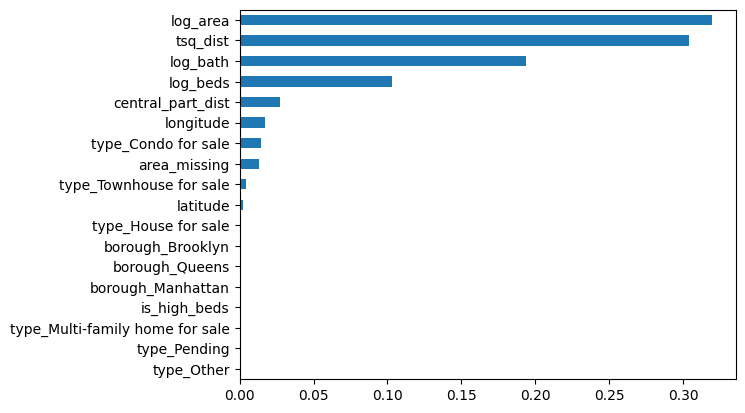

In [66]:
pd.Series(tree.feature_importances_, index=X.columns).sort_values().plot(kind='barh')

MAE: $742,823
R2: 0.609
CV R2: 0.634 ± 0.044


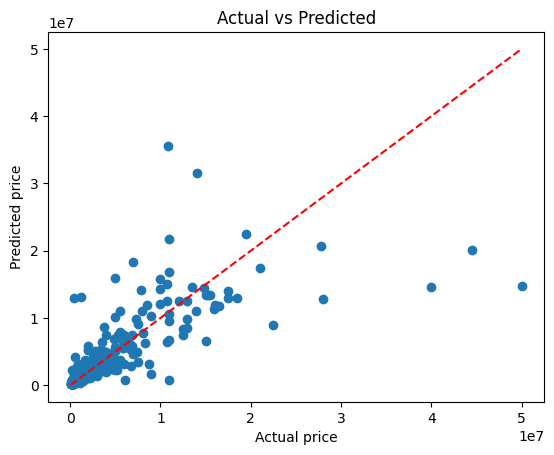

In [67]:
# ID: 
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    min_impurity_decrease=1e5
)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Metrics
print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.0f}")
r2 = r2_score(y_test, y_pred)
print(f"R2: {r2:.3f}")
# Cross-validated R2
from sklearn.model_selection import cross_val_score
cv_r2 = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"CV R2: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted')
plt.show()

In [68]:
new_entry = {
    'ID': 11,
    'Model': 'RandomForestRegressor',
    'Features': all_features_expanded,
    'Params': {'n_estimators':100,
    'max_depth':15,
    'min_samples_leaf':5,
    'min_impurity_decrease':1e5},
    'MAE': 738579,
    'R2': 0.605,
    'Cross_val_R2': 0.622,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [69]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing
4,5,LinearRegression,"[beds, bath, propertysqft, type_Condo for sale...",None,1471016.510,0.275,0.349,
5,6,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",None,1553327.370,0.382,0.350,On adding lat long changes insignificant
6,7,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",873832.230,0.468,0.580,
7,None,Feature Engineering,"[central_part_dist, tsq_dist]",,NaN,NaN,NaN,
8,8,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",,1549143.360,0.388,0.353,
9,9,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",843038.060,0.546,0.589,


<Axes: xlabel='tsq_dist', ylabel='price'>

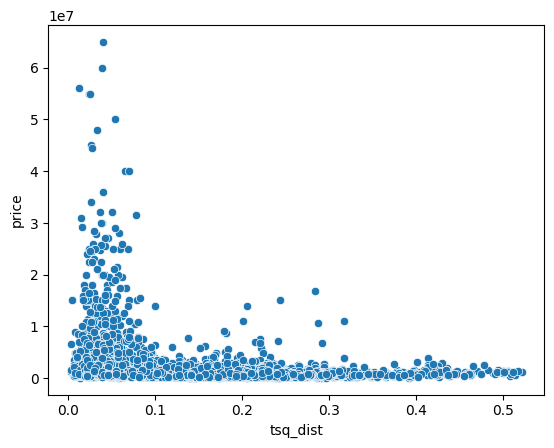

In [70]:
sns.scatterplot(df, x='tsq_dist', y='price')

<Axes: xlabel='tsq_dist', ylabel='Count'>

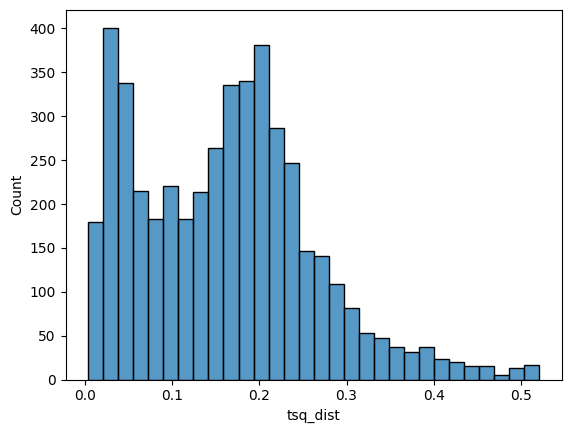

In [71]:
sns.histplot(df, x='tsq_dist')

In [72]:
# export experiment log
experiment_log.to_csv('../outputs/experiment_log.csv', mode='w', header=True, index=False)